# Exploratory Data Analysis — `postings.csv`

**Scope:** this notebook covers only the main table, `postings.csv`. The related tables in `companies/`, `jobs/`, and `mappings/` are intentionally left out for now — they'll get their own EDA once we understand the core table on its own.

**Goal:** understand the shape, structure, and quality of the data before making any cleaning decisions. No modeling here — this is purely descriptive.

Each section below states what we're checking and why, shows the evidence, and — where a cleaning decision would normally happen — flags it as an open question instead of deciding for you.

## TL;DR

- **Clean primary key** — 123,849 postings, 0 full-row duplicates, 0 duplicate `job_id`. No dedup work needed.
- **Missingness is the main constraint** — `skills_desc` (98%), the salary fields (71–95%), and `remote_allowed` (87.7%) are mostly empty. Structured fields alone won't carry the analysis.
- **Confirms the NLP plan** — the dataset's own skill field is 98% empty, and the alternate `job_skills.csv` only has 35 broad functional categories (not real skills). Skill extraction has to come from parsing `description` text, as scoped in the proposal.
- **Salary needs outlier handling** — median `normalized_salary` is $81,500 but the max is $535.6M, an obvious data error; only 29% of postings have any salary data at all.
- **Nothing has been cleaned yet** — this notebook is observation only. Open questions are listed in Section 9 for discussion before any cleaning step.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")

BASE = "./"  # postings.csv lives alongside this notebook

## 2. Load the data

In [2]:
postings = pd.read_csv(f"{BASE}postings.csv")
postings.head()

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,min_salary,formatted_work_type,applies,original_listed_time,remote_allowed,job_posting_url,application_url,application_type,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,17.0,Full-time,2.0,1.713398e+12,NaN,https://www.linkedin.com/jobs/view/921716/?trk...,NaN,ComplexOnsiteApply,1.715990e+12,NaN,NaN,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,30.0,Full-time,NaN,1.712858e+12,NaN,https://www.linkedin.com/jobs/view/1829192/?tr...,NaN,ComplexOnsiteApply,1.715450e+12,NaN,NaN,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,45000.0,Full-time,NaN,1.713278e+12,NaN,https://www.linkedin.com/jobs/view/10998357/?t...,NaN,ComplexOnsiteApply,1.715870e+12,NaN,NaN,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,140000.0,Full-time,NaN,1.712896e+12,NaN,https://www.linkedin.com/jobs/view/23221523/?t...,NaN,ComplexOnsiteApply,1.715488e+12,NaN,NaN,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,60000.0,Full-time,NaN,1.713452e+12,NaN,https://www.linkedin.com/jobs/view/35982263/?t...,NaN,ComplexOnsiteApply,1.716044e+12,NaN,NaN,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


## 3. Shape and structure

Basic row/column counts and the full column list, so we have a reference point before digging in.

In [3]:
print(f"Rows: {postings.shape[0]:,}")
print(f"Columns: {postings.shape[1]}")
print()
print("Column names:")
for col in postings.columns:
    print(f"  - {col}")

Rows: 123,849
Columns: 31

Column names:
  - job_id
  - company_name
  - title
  - description
  - max_salary
  - pay_period
  - location
  - company_id
  - views
  - med_salary
  - min_salary
  - formatted_work_type
  - applies
  - original_listed_time
  - remote_allowed
  - job_posting_url
  - application_url
  - application_type
  - expiry
  - closed_time
  - formatted_experience_level
  - skills_desc
  - listed_time
  - posting_domain
  - sponsored
  - work_type
  - currency
  - compensation_type
  - normalized_salary
  - zip_code
  - fips


## 4. Data types

`.info()` shows the dtype pandas inferred for each column plus non-null counts in one pass. Things worth watching for:
- Columns that are conceptually integers (like IDs or timestamps) but show up as `float64` — usually because missing values force pandas to use floats.
- Timestamp-like columns (`listed_time`, `expiry`, `closed_time`, `original_listed_time`) are stored as raw epoch milliseconds, not datetimes — we'll need to convert them before any time-based analysis, but we won't do that conversion yet.
- `job_id` and `company_id` are identifiers, not measurements — they'll show up under "numeric dtypes" below but shouldn't be treated as continuous variables.

In [4]:
postings.info()

<class 'pandas.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  str    
 2   title                       123849 non-null  str    
 3   description                 123842 non-null  str    
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   str    
 6   location                    123849 non-null  str    
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  str    
 12  applies                     23320 non-null   float64
 13  original_listed_time     

## 5. Duplicate records

Two different duplicate checks, because they mean different things:
1. **Full-row duplicates** — identical rows across every column. Usually a sign of an ingestion/export error.
2. **Duplicate `job_id`** — `job_id` looks like it should be a unique primary key for a posting. If the same `job_id` appears more than once, we need to know whether those rows are truly identical or represent conflicting records (e.g. a reposted/updated listing) before deciding how to deduplicate.

In [5]:
full_dupes = postings.duplicated(keep=False)
print(f"Full-row duplicate rows: {full_dupes.sum():,} ({full_dupes.mean()*100:.2f}%)")
postings[full_dupes].head(10)

Full-row duplicate rows: 0 (0.00%)


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,min_salary,formatted_work_type,applies,original_listed_time,remote_allowed,job_posting_url,application_url,application_type,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips


In [6]:
id_dupes = postings["job_id"].duplicated(keep=False)
print(f"Rows sharing a job_id with another row: {id_dupes.sum():,} ({id_dupes.mean()*100:.2f}%)")
print(f"Unique job_id values: {postings['job_id'].nunique():,} vs {postings.shape[0]:,} total rows")

# If duplicate job_ids exist, show one group so we can see whether they're identical
# or genuinely different rows sharing an id.
if id_dupes.any():
    example_id = postings.loc[id_dupes, "job_id"].iloc[0]
    display(postings[postings["job_id"] == example_id])

Rows sharing a job_id with another row: 0 (0.00%)
Unique job_id values: 123,849 vs 123,849 total rows


**Open question (do not resolve yet):** if either check above finds duplicates, we need to decide together whether to drop them, and on what key. No rows have been removed in this notebook.

## 6. Missing values

For every column: how many values are missing, and what fraction of the table that represents. Sorted worst-first so the biggest gaps are immediately visible.

In [7]:
missing = pd.DataFrame({
    "missing_count": postings.isna().sum(),
    "missing_pct": (postings.isna().mean() * 100).round(1),
}).sort_values("missing_pct", ascending=False)
missing

,missing_count,missing_pct
closed_time,122776,99.1
skills_desc,121410,98.0
med_salary,117569,94.9
remote_allowed,108603,87.7
applies,100529,81.2
min_salary,94056,75.9
max_salary,94056,75.9
currency,87776,70.9
compensation_type,87776,70.9
pay_period,87776,70.9


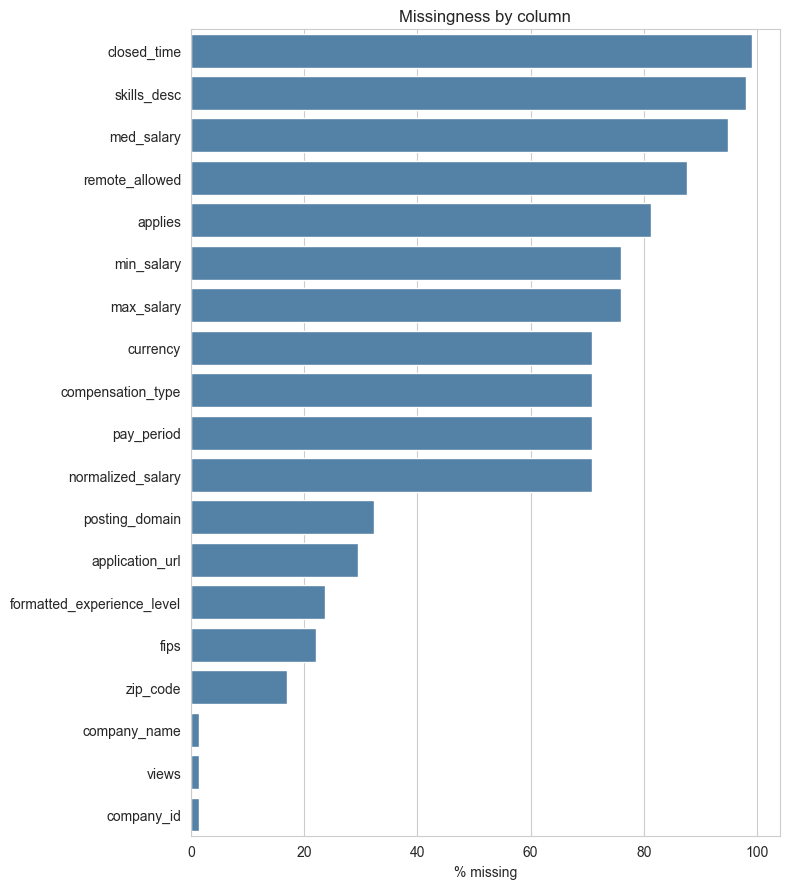

In [8]:
fig, ax = plt.subplots(figsize=(8, 9))
missing_nonzero = missing[missing["missing_pct"] > 0]
sns.barplot(x=missing_nonzero["missing_pct"], y=missing_nonzero.index, ax=ax, color="steelblue")
ax.set_xlabel("% missing")
ax.set_ylabel("")
ax.set_title("Missingness by column")
plt.tight_layout()
plt.show()

**Open question (do not resolve yet):** several columns are missing 70%+ of values (e.g. the salary fields, `remote_allowed`, `skills_desc`). Before dropping or imputing anything, we should discuss:
- Is missing salary data missing-at-random, or does it correlate with certain job types/industries?
- Does `remote_allowed` missing mean "not remote" or "not specified"? These are different assumptions with different implications.

No columns have been dropped and no values have been imputed in this notebook.

## 7. Categorical variables

First step: separate low-cardinality columns (a handful of repeated values — good candidates for distribution/bar-chart analysis) from high-cardinality columns (mostly-unique free text like `title`, `company_name`, `description` — not meaningfully summarized as a bar chart).

In [9]:
categorical_cols = postings.select_dtypes(include=["object"]).columns
cardinality = postings[categorical_cols].nunique().sort_values()
cardinality

C:\Users\User\AppData\Local\Temp\ipykernel_31308\1713195391.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = postings.select_dtypes(include=["object"]).columns


compensation_type                  1
application_type                   4
pay_period                         5
currency                           6
formatted_experience_level         6
formatted_work_type                7
work_type                          7
skills_desc                     2212
posting_domain                  4443
location                        8526
company_name                   24428
title                          72521
application_url                84800
description                   107827
job_posting_url               123849
dtype: int64

Based on the cardinality table above, the following look like genuine low-cardinality categoricals worth a full distribution: `pay_period`, `formatted_work_type`, `work_type`, `formatted_experience_level`, `currency`, `compensation_type`, `application_type`. We'll look at each in turn.

In [10]:
low_card_cols = ["pay_period", "formatted_work_type", "work_type",
                  "formatted_experience_level", "currency", "compensation_type", "application_type"]

for col in low_card_cols:
    print(f"--- {col} ---")
    print(postings[col].value_counts(dropna=False))
    print()

--- pay_period ---
pay_period
NaN         87776
YEARLY      20628
HOURLY      14741
MONTHLY       518
WEEKLY        177
BIWEEKLY        9
Name: count, dtype: int64

--- formatted_work_type ---
formatted_work_type
Full-time     98814
Contract      12117
Part-time      9696
Temporary      1190
Internship      983
Volunteer       562
Other           487
Name: count, dtype: int64

--- work_type ---
work_type
FULL_TIME     98814
CONTRACT      12117
PART_TIME      9696
TEMPORARY      1190
INTERNSHIP      983
VOLUNTEER       562
OTHER           487
Name: count, dtype: int64

--- formatted_experience_level ---
formatted_experience_level
Mid-Senior level    41489
Entry level         36708
NaN                 29409
Associate            9826
Director             3746
Internship           1449
Executive            1222
Name: count, dtype: int64

--- currency ---
currency
NaN    87776
USD    36058
EUR        6
CAD        3
BBD        2
AUD        2
GBP        2
Name: count, dtype: int64

--- compen

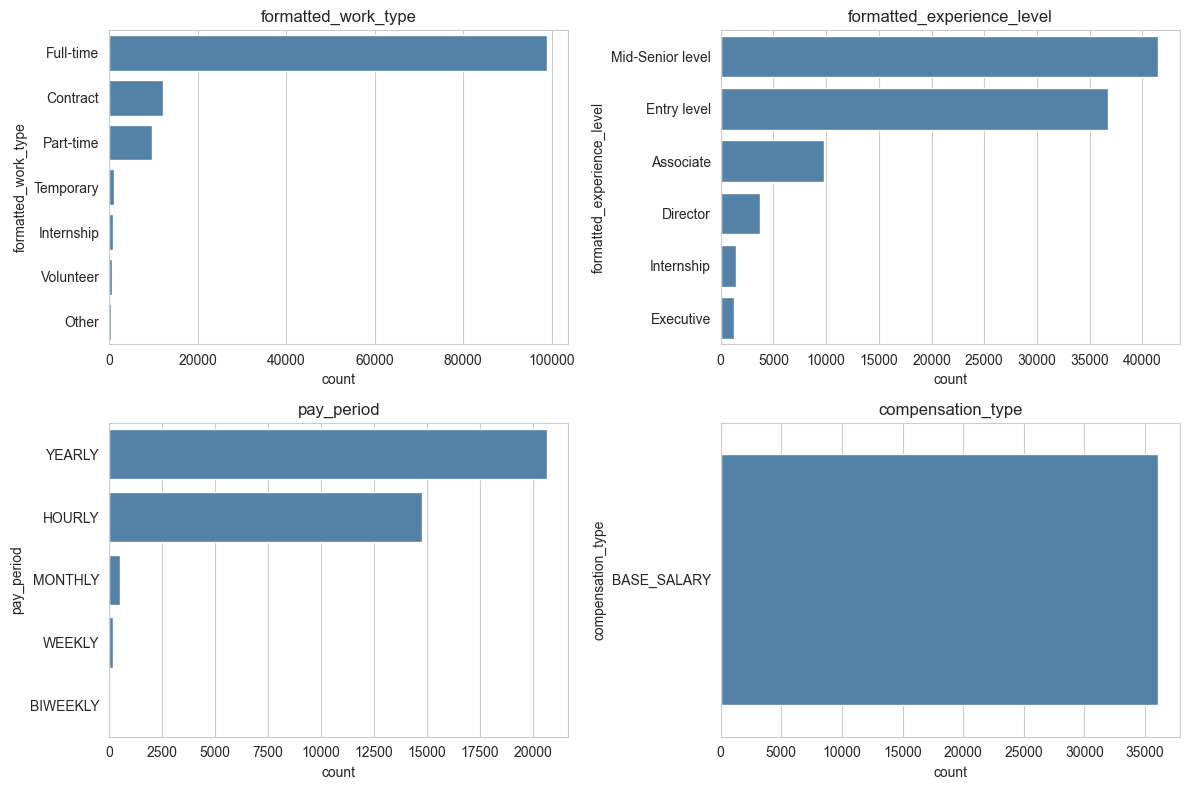

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_cols = ["formatted_work_type", "formatted_experience_level", "pay_period", "compensation_type"]

for ax, col in zip(axes.flat, plot_cols):
    counts = postings[col].value_counts(dropna=False).head(10)
    sns.barplot(x=counts.values, y=counts.index.astype(str), ax=ax, color="steelblue")
    ax.set_title(col)
    ax.set_xlabel("count")

plt.tight_layout()
plt.show()

For the high-cardinality columns (`title`, `company_name`, `location`), a full distribution isn't meaningful, but looking at the most frequent values is still useful context.

In [12]:
for col in ["title", "company_name", "location"]:
    print(f"--- Top 10 {col} values ({postings[col].nunique():,} unique total) ---")
    print(postings[col].value_counts().head(10))
    print()

--- Top 10 title values (72,521 unique total) ---
title
Sales Manager                      673
Customer Service Representative    373
Project Manager                    354
Administrative Assistant           254
Senior Accountant                  238
Executive Assistant                228
Salesperson                        211
Registered Nurse                   210
Receptionist                       204
Staff Accountant                   200
Name: count, dtype: int64

--- Top 10 company_name values (24,428 unique total) ---
company_name
Liberty Healthcare and Rehabilitation Services    1108
The Job Network                                   1003
J. Galt                                            604
TEKsystems                                         529
Lowe's Companies, Inc.                             527
Ingersoll Rand                                     517
Capital One                                        496
Cogent Communications                              476
Insight Global   

## 8. Numerical variables

First, `.describe()` on everything pandas thinks is numeric. Note this will include `job_id`, `company_id`, `zip_code`, `fips`, and the epoch-millisecond timestamp columns — these are identifiers/timestamps, not measurements, so their mean/std are not meaningful and we'll exclude them from the histogram step below.

In [13]:
postings.describe()

,job_id,max_salary,company_id,views,med_salary,min_salary,applies,original_listed_time,remote_allowed,expiry,closed_time,listed_time,sponsored,normalized_salary,zip_code,fips
count,1.238490e+05,2.979300e+04,1.221320e+05,122160.000000,6280.000000,2.979300e+04,23320.000000,1.238490e+05,15246.0,1.238490e+05,1.073000e+03,1.238490e+05,123849.0,3.607300e+04,102977.000000,96434.000000
mean,3.896402e+09,9.193942e+04,1.220401e+07,14.618247,22015.619876,6.491085e+04,10.591981,1.713152e+12,1.0,1.716213e+12,1.712928e+12,1.713204e+12,0.0,2.053270e+05,50400.491887,28713.879887
std,8.404355e+07,7.011101e+05,2.554143e+07,85.903598,52255.873846,4.959738e+05,29.047395,4.848209e+08,0.0,2.321394e+09,3.622893e+08,3.989122e+08,0.0,5.097627e+06,30252.232515,16015.929825
min,9.217160e+05,1.000000e+00,1.009000e+03,1.000000,0.000000,1.000000e+00,1.000000,1.701811e+12,1.0,1.712903e+12,1.712346e+12,1.711317e+12,0.0,0.000000e+00,1001.000000,1003.000000
25%,3.894587e+09,4.828000e+01,1.435200e+04,3.000000,18.940000,3.700000e+01,1.000000,1.712863e+12,1.0,1.715481e+12,1.712670e+12,1.712886e+12,0.0,5.200000e+04,24112.000000,13121.000000
50%,3.901998e+09,8.000000e+04,2.269650e+05,4.000000,25.500000,6.000000e+04,3.000000,1.713395e+12,1.0,1.716042e+12,1.712670e+12,1.713408e+12,0.0,8.150000e+04,48059.000000,29183.000000
75%,3.904707e+09,1.400000e+05,8.047188e+06,8.000000,2510.500000,1.000000e+05,8.000000,1.713478e+12,1.0,1.716088e+12,1.713283e+12,1.713484e+12,0.0,1.250000e+05,78201.000000,42077.000000
max,3.906267e+09,1.200000e+08,1.034730e+08,9975.000000,750000.000000,8.500000e+07,967.000000,1.713573e+12,1.0,1.729125e+12,1.713562e+12,1.713573e+12,0.0,5.356000e+08,99901.000000,56045.000000


The genuinely continuous/count variables are: `max_salary`, `min_salary`, `med_salary`, `normalized_salary`, `views`, `applies`. We'll look at their distributions on the non-missing subset only (no imputation).

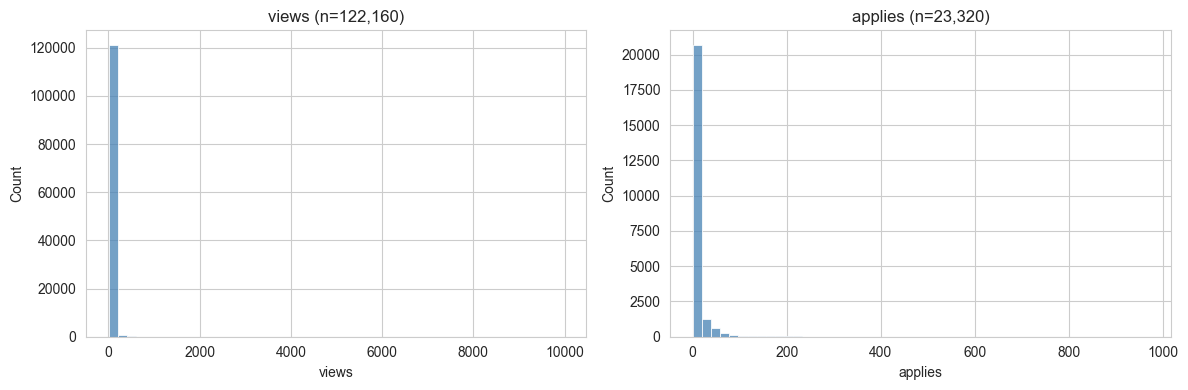

,views,applies
count,122160.000000,23320.000000
mean,14.618247,10.591981
std,85.903598,29.047395
min,1.000000,1.000000
25%,3.000000,1.000000
50%,4.000000,3.000000
75%,8.000000,8.000000
max,9975.000000,967.000000


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(postings["views"].dropna(), bins=50, ax=axes[0], color="steelblue")
axes[0].set_title(f"views (n={postings['views'].notna().sum():,})")

sns.histplot(postings["applies"].dropna(), bins=50, ax=axes[1], color="steelblue")
axes[1].set_title(f"applies (n={postings['applies'].notna().sum():,})")

plt.tight_layout()
plt.show()

postings[["views", "applies"]].describe()

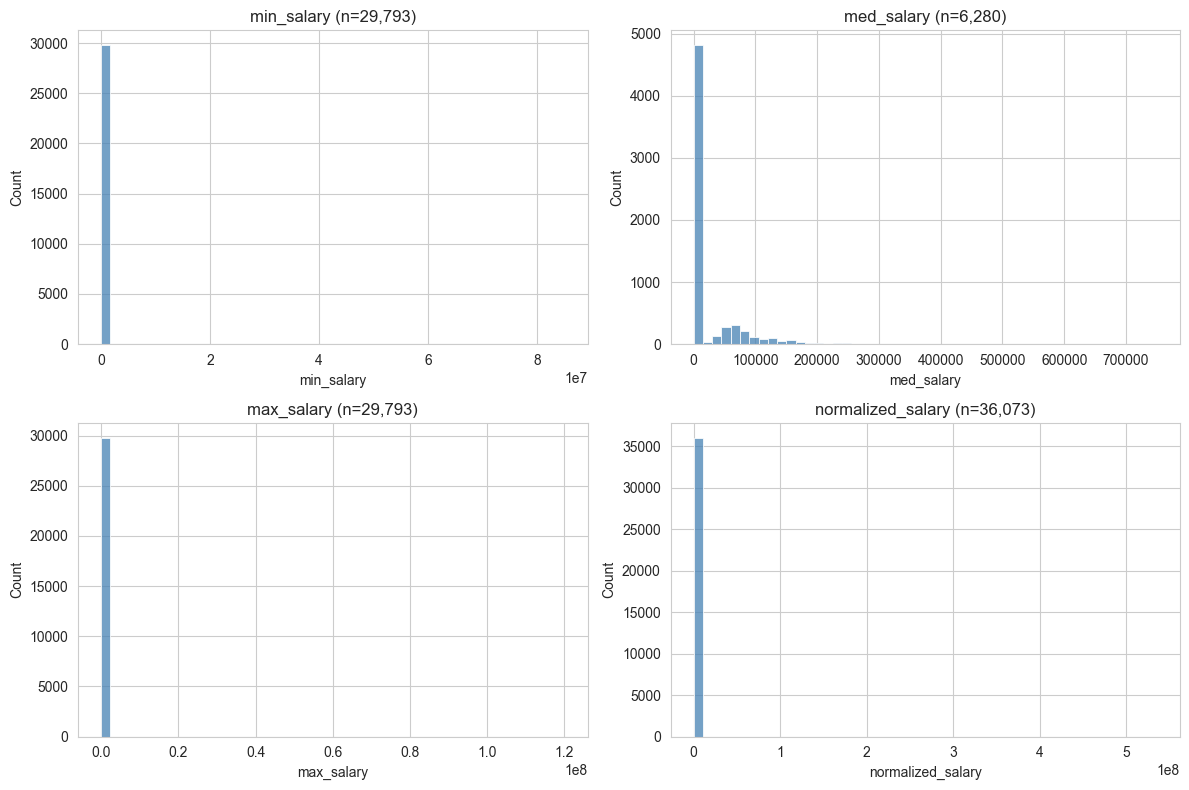

,min_salary,med_salary,max_salary,normalized_salary
count,2.979300e+04,6280.000000,2.979300e+04,3.607300e+04
mean,6.491085e+04,22015.619876,9.193942e+04,2.053270e+05
std,4.959738e+05,52255.873846,7.011101e+05,5.097627e+06
min,1.000000e+00,0.000000,1.000000e+00,0.000000e+00
25%,3.700000e+01,18.940000,4.828000e+01,5.200000e+04
50%,6.000000e+04,25.500000,8.000000e+04,8.150000e+04
75%,1.000000e+05,2510.500000,1.400000e+05,1.250000e+05
max,8.500000e+07,750000.000000,1.200000e+08,5.356000e+08


In [15]:
salary_cols = ["min_salary", "med_salary", "max_salary", "normalized_salary"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, salary_cols):
    data = postings[col].dropna()
    sns.histplot(data, bins=50, ax=ax, color="steelblue")
    ax.set_title(f"{col} (n={len(data):,})")

plt.tight_layout()
plt.show()

postings[salary_cols].describe()

**Open question (do not resolve yet):** salary histograms are likely to be heavily right-skewed with some extreme outliers (e.g. hourly vs. yearly rates mixed together, since `pay_period` varies by row). Before doing anything about outliers or skew, we should check whether `normalized_salary` already accounts for `pay_period` differences, and decide together whether any filtering (e.g. by `currency == "USD"`, or capping extreme values) is appropriate — and on what basis.

## 9. Summary of open questions

Nothing has been dropped, imputed, or transformed in this notebook — it's observation only. Decisions to make together before any cleaning step:

1. **Duplicates** — did section 5 find any full-row or `job_id` duplicates, and if so, how should they be resolved?
2. **High-missing columns** — `closed_time`, `skills_desc`, `med_salary`, `remote_allowed`, and the salary trio are all missing 70%+. Drop, keep as-is, or impute? On what basis?
3. **`remote_allowed` semantics** — does missing mean "not remote" or "unspecified"?
4. **Salary comparability** — `pay_period` and `currency` vary by row; does `normalized_salary` already resolve this, and are there outliers worth capping or excluding?
5. **Timestamp columns** — currently raw epoch milliseconds; do we need them converted to datetimes for a later stage (e.g. seasonality of postings)?
6. **High-cardinality text fields** (`title`, `company_name`, `description`, `location`) — these will likely need normalization/standardization before use in the recommendation pipeline, but that's out of scope for this EDA pass.